<a href="https://colab.research.google.com/github/nsidicarocep/econometria_interactiva/blob/main/codigos/1_regresion_simple_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regresión Simple en R

## Econometría I — Del cálculo a mano a la salida de lm()

### Profesor Luis E. Peñafiel

> **Antes de empezar:** este material asume que ya resolviste a mano el Ejercicio 3 de la Práctica de Clase 3 (temperatura y consumo de helados). Si todavía no lo hiciste, te conviene resolverlo en papel primero — acá lo vamos a retomar para mostrar que R hace *exactamente la misma cuenta*, solo que más rápido. No hace falta saber programar: cada bloque de código viene explicado línea por línea, y lo importante no es que sepas escribirlo, sino que sepas **leer lo que devuelve**.

## 📘 Glosario rápido

| Término | En criollo |
|------------------------------------|------------------------------------|
| **`lm()`** | La función de R que ajusta un modelo de regresión lineal ("linear model"). Es el equivalente en R a resolver las fórmulas de $\hat\beta_0$ y $\hat\beta_1$ a mano. |
| **`summary()`** | Le pedís a R el "resumen" de una regresión ya estimada: coeficientes, errores estándar, $R^2$, etc. Es la tabla que venís interpretando en la Sección 4 de tus prácticas. |
| **Residual standard error** | Es $\hat\sigma$, el error estándar de la regresión — lo mismo que calculaste a mano dividiendo $\sum \hat u_i^2$ por $(n-2)$. |
| \*\*Pr(\> | t |
| **Multiple R-squared** | El $R^2$ que ya conocés. En regresión simple, "Multiple" es solo el nombre genérico que usa R (aunque haya un solo regresor). |

------------------------------------------------------------------------

## 🧩 Bloque 0 — Lo que ya resolviste a mano

Retomemos el Ejercicio 3 de la Clase 3: temperatura máxima del día ($x$) y helados vendidos ($y$), para 5 días.

In [ ]:
x <- c(20, 24, 28, 32, 36)   # temperatura (°C)
y <- c(48, 56, 70, 82, 94)   # helados vendidos

datos <- data.frame(temperatura = x, helados = y)
datos

temperatura,helados
<dbl>,<dbl>
20,48
24,56
28,70
32,82
36,94


Ahora repliquemos, paso a paso, las mismas cuentas que hiciste a mano con la fórmula:

$$\hat\beta_1 = \frac{\sum(x_i - \bar x)(y_i - \bar y)}{\sum(x_i - \bar x)^2} \qquad \hat\beta_0 = \bar y - \hat\beta_1 \bar x$$

In [ ]:
x_barra <- mean(x)
y_barra <- mean(y)

Sxy <- sum((x - x_barra) * (y - y_barra))
Sxx <- sum((x - x_barra)^2)

beta1_manual <- Sxy / Sxx
beta0_manual <- y_barra - beta1_manual * x_barra

cat("beta1 (manual):", beta1_manual, "\n")
cat("beta0 (manual):", beta0_manual, "\n")

beta1 (manual): 2.95 
beta0 (manual): -12.6 


Si te dio $\hat\beta_1 = 2.95$ y $\hat\beta_0 = -12.6$ en el papel, estos números tienen que coincidir. Ahora hagamos que R estime el mismo modelo con `lm()`:

In [ ]:
modelo_toy <- lm(helados ~ temperatura, data = datos)
summary(modelo_toy)


Call:
lm(formula = helados ~ temperatura, data = datos)

Residuals:
         1          2          3          4          5 
 1.600e+00 -2.200e+00 -4.774e-15  2.000e-01  4.000e-01 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -12.6000     3.5944  -3.505  0.03933 *  
temperatura   2.9500     0.1258  23.444  0.00017 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.592 on 3 degrees of freedom
Multiple R-squared:  0.9946,	Adjusted R-squared:  0.9928 
F-statistic: 549.6 on 1 and 3 DF,  p-value: 0.00017


### 🔎 Qué mirar acá

Fijate que el coeficiente de `temperatura` en la tabla (`Estimate`) es **2.95**, y el `(Intercept)` es **-12.6** — los mismos valores que calculaste con la fórmula. `lm()` no hace ninguna magia distinta: resuelve exactamente las mismas ecuaciones normales de mínimos cuadrados, solo que se las delegamos a la computadora en vez de hacerlas con calculadora. También el `Residual standard error` (1.592) coincide con el $\hat\sigma$ que sacaste a mano dividiendo la suma de residuos al cuadrado por $(n-2)=3$.

Esta es la idea que vamos a usar en **todos** los notebooks de la materia: primero resolver a mano (o retomar lo ya resuelto), después verificar con R, y recién ahí avanzar a datasets grandes donde hacerlo a mano ya no es viable.

### 📊 El gráfico de dispersión con la recta ajustada

Esto es lo mismo que te pedía el inciso (f) del Ejercicio 3: graficar los puntos, trazar la recta y marcar los residuos. En R:

`geom_smooth()` using formula = 'y ~ x'


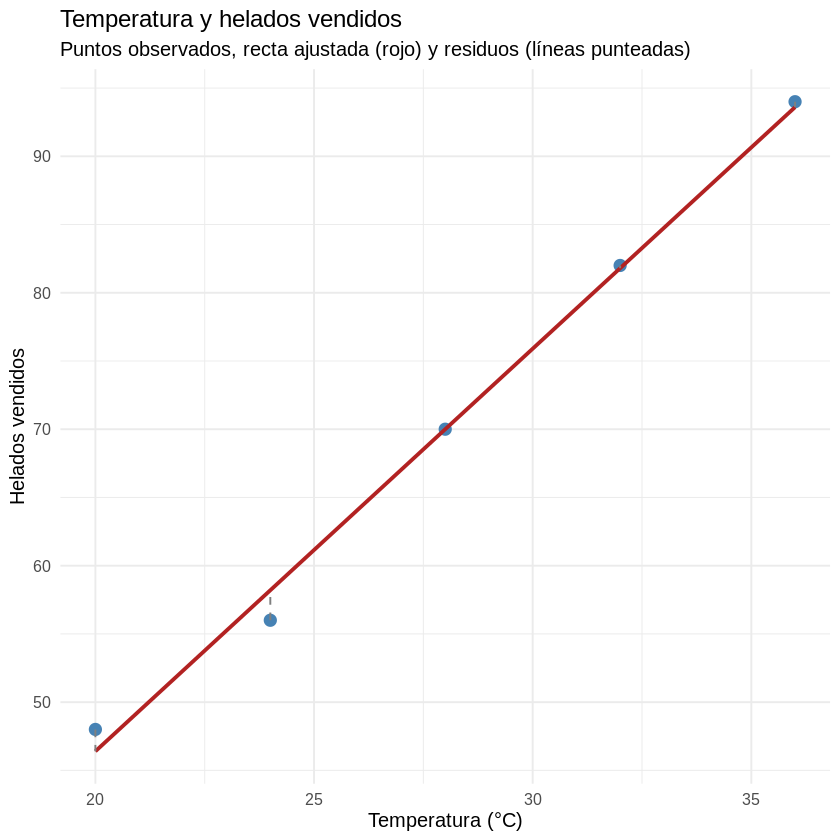

In [ ]:
library(ggplot2)

ggplot(datos, aes(x = temperatura, y = helados)) +
  geom_point(size = 3, color = "steelblue") +
  geom_smooth(method = "lm", se = FALSE, color = "firebrick") +
  geom_segment(aes(xend = temperatura, yend = fitted(modelo_toy)),
               linetype = "dashed", color = "grey50") +
  labs(title = "Temperatura y helados vendidos",
       subtitle = "Puntos observados, recta ajustada (rojo) y residuos (líneas punteadas)",
       x = "Temperatura (°C)", y = "Helados vendidos") +
  theme_minimal(base_size = 12)

### 🔎 Qué mirar en el gráfico

Cada línea punteada gris es un residuo $\hat u_i$: la distancia vertical entre el punto observado y la recta. El día más "raro" es el de 24°C, donde se vendieron menos helados de lo que la recta predice (residuo de -2.2) — la recta minimiza la suma de estos residuos al cuadrado, pero eso no significa que pase exactamente por cada punto.

------------------------------------------------------------------------

## 📥 Bloque 1 — Un dataset real: salario y educación

Vamos a usar el mismo dataset que aparece en el Ejercicio 1 de la Sección 4 de tu práctica (salario por hora en función de años de educación, $n=526$). Es el dataset `wage1`, del libro de texto de Wooldridge — el "clásico" para aprender regresión en econometría aplicada.

In [ ]:
# Si no tenés el paquete instalado: install.packages("wooldridge")
install.packages("wooldridge")
library(wooldridge)
data(wage1)

head(wage1[, c("wage", "educ")])

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



,wage,educ
,<dbl>,<int>
1,3.10,11
2,3.24,12
3,3.00,11
4,6.00,8
5,5.30,12
6,8.75,16


| Columna | Qué es                       |
|---------|------------------------------|
| `wage`  | Salario por hora, en dólares |
| `educ`  | Años de educación formal     |

$n = `r nrow(wage1)`$ trabajadores — el mismo tamaño de muestra que ya viste en el enunciado.

------------------------------------------------------------------------

## 🔵 Bloque 2 — Estimar y leer el `summary()`

In [ ]:
modelo_salario <- lm(wage ~ educ, data = wage1)
summary(modelo_salario)

### 🔎 Leyendo la tabla parte por parte

-   **`Estimate` de `educ` (0.5414):** por cada año adicional de educación, el salario por hora predicho aumenta en 0.54 dólares, manteniendo todo lo demás constante (acá no hay "todo lo demás" porque es regresión simple).
-   **`Std. Error` (0.0533):** la precisión de esa estimación — cuanto más chico, más preciso el coeficiente.
-   **`t value` (10.167) y `Pr(>|t|)` (\<2e-16):** el estadístico $t = \hat\beta_1 / se(\hat\beta_1)$ y su p-valor. Como el p-valor es prácticamente cero, rechazamos $H_0: \beta_1 = 0$ — la educación sí tiene efecto sobre el salario.
-   **`(Intercept)` (-0.9049):** el salario predicho para alguien con cero años de educación. Fijate que da **negativo** — no tiene sentido económico literal (nadie cobra un salario negativo), pero es matemáticamente correcto: es solo la extrapolación de la recta hasta $x=0$, un valor fuera del rango real de datos. Esto es un ejemplo del tipo de resultado "raro" que conviene poder explicar en vez de ignorar.
-   **`Residual standard error` (3.378):** el $\hat\sigma$ de este modelo — la dispersión típica de los residuos, en dólares por hora.
-   **`Multiple R-squared` (0.1648):** la educación explica el 16.5% de la variabilidad del salario. Es bajo, y tiene sentido: el salario depende de muchas otras cosas (experiencia, industria, etc.) que en este modelo simple no están.

Compará estos números con lo que ya escribiste en la Sección 4 de tu práctica — tienen que ser exactamente los mismos, porque es el mismo dataset.

### 📊 Visualizando 526 observaciones

Con un dataset real ya no tiene sentido marcar cada residuo individual como en el Bloque 0 (serían 526 líneas), pero el gráfico de dispersión con la recta ajustada sigue siendo la mejor forma de ver qué tan bien (o mal) ajusta el modelo:

In [ ]:
ggplot(wage1, aes(x = educ, y = wage)) +
  geom_point(alpha = 0.35, color = "steelblue") +
  geom_smooth(method = "lm", se = TRUE, color = "firebrick") +
  labs(title = "Salario por hora y años de educación",
       subtitle = "n = 526 trabajadores — recta ajustada con banda de confianza",
       x = "Años de educación", y = "Salario por hora (USD)") +
  theme_minimal(base_size = 12)

### 🔎 Qué mirar en el gráfico

La nube de puntos es mucho más dispersa que en el ejemplo de juguete — coherente con el $R^2$ bajo (0.16) que vimos en la tabla. La banda gris alrededor de la recta es el intervalo de confianza para el valor medio predicho: notá que es angosta cerca del centro de los datos (donde hay más observaciones) y se ensancha en los extremos (pocos años de educación muy bajos o muy altos), el mismo fenómeno que vas a formalizar en la Clase 8 con los intervalos de predicción.

------------------------------------------------------------------------

## 🟢 Bloque 3 — Prediciendo con el modelo

In [ ]:
nuevos_educ <- data.frame(educ = c(12, 16))
predict(modelo_salario, newdata = nuevos_educ)

### 🔎 Qué nos dice esto

Para alguien con 12 años de educación (secundario completo), el modelo predice un salario de aproximadamente \$5.6 por hora; con 16 años (universitario completo), \$7.75. La diferencia entre ambos (\$2.16) es simplemente $4 \times \hat\beta_1 = 4 \times 0.5414$ — cuatro años adicionales de educación, multiplicados por el efecto marginal.

------------------------------------------------------------------------

## ✍️ Para vos — Completá el código

Ahora te toca a vos. Es el Ejercicio 4 de tu práctica: antigüedad en la empresa y salario mensual, con $n=200$ empleados. Ya generamos los datos (simulados, calibrados para acercarse a los resultados del enunciado); a vos te falta completar la línea del modelo y correrla.

In [ ]:
set.seed(123)
antiguedad <- pmax(round(rnorm(200, mean = 10, sd = 3.1)), 0)
salario    <- 185.32 + 12.76 * antiguedad + rnorm(200, mean = 0, sd = 45.67)

datos_antiguedad <- data.frame(antiguedad, salario)
head(datos_antiguedad)

> ⚠️ Como los datos son simulados con un componente aleatorio, los números que te van a salir van a estar **cerca** de los del enunciado (Intercepto ≈ 185.32, pendiente ≈ 12.76) pero no van a coincidir exactamente — eso es esperable, no un error. Es el mismo fenómeno de variabilidad muestral que vimos en la Clase 2: cada muestra da una estimación distinta, aunque las dos estén "apuntando" al mismo valor poblacional.

Completá los dos espacios en blanco — recordá que en R la sintaxis es `lm(variable_dependiente ~ variable_independiente, data = ...)` — y corré el chunk:

In [ ]:
modelo_antiguedad <- lm(___ ~ ___, data = datos_antiguedad)
summary(modelo_antiguedad)

Una vez que lo corras, respondé (son las mismas preguntas del inciso b, c y e del Ejercicio 4 de tu práctica, pero ahora con la salida que generaste vos):

1.  ¿Cuál es el salario predicho para un empleado recién ingresado (antigüedad = 0)? ¿Y para uno con 15 años de antigüedad?
2.  ¿Cuál es el error estándar de $\hat\beta_0$? ¿Y el de $\hat\beta_1$?
3.  Interpretá los coeficientes: ¿qué significa económicamente la pendiente?

------------------------------------------------------------------------

## 🏁 Cierre — Así podría aparecer en el examen

En el parcial de lápiz y papel podés encontrarte con una tabla como esta, sin el código que la generó — la consigna sería igual a la Sección 4 de tu práctica:

```         
Call:
lm(formula = precio ~ superficie)

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  10.8356     6.2738   1.727   0.0877 .
superficie    1.4723     0.0842  17.485   <2e-16 ***

Residual standard error: 15.12 on 86 degrees of freedom
Multiple R-squared: 0.7805, Adjusted R-squared: 0.778
```

Si podés responder sin dudar *qué es cada número, de dónde sale, y qué significa*, este notebook cumplió su objetivo — independientemente de si alguna vez escribís una línea de código en R.

------------------------------------------------------------------------

*Notebook piloto — Encuentro Regresión Simple. Estructura: Bloque 0 (verificación manual + gráfico) → Bloque 1 (datos reales) → Bloque 2 (lectura del summary + gráfico) → Bloque 3 (predicción) → Ejercicio semi-guiado (completar código) → Cierre orientado a examen.*

*Criterio de datos para los próximos notebooks de la serie (Múltiple, Formas Funcionales, Inferencia I/II, Contrastación): priorizar datos simulados calibrados para reproducir los coeficientes exactos del enunciado en papel, y sumar además — aunque el notebook quede más largo — un dataset real alternativo cuando exista uno razonablemente accesible en R (paquetes como `wooldridge`, `AER`, o similares).*